In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Target column : diagnosis 
#Task type : Binary Classification 
#Classes : Malignant (M), Benign (B)

In [3]:
df = pd.read_csv("cancer-diagnosis.csv")

In [4]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [6]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [7]:
df["Unnamed: 32"].value_counts

<bound method IndexOpsMixin.value_counts of 0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
       ..
564   NaN
565   NaN
566   NaN
567   NaN
568   NaN
Name: Unnamed: 32, Length: 569, dtype: float64>

In [8]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [9]:
df.drop(["id","Unnamed: 32"], axis = 1, inplace = True)

In [10]:
df.corr(numeric_only = True)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
radius_mean,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413
fractal_dimension_mean,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,...,-0.253691,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297


In [11]:
df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [12]:
df["diagnosis_num"] = (df["diagnosis"] == "M").astype(int)

In [13]:
df["diagnosis_num"].value_counts()

diagnosis_num
0    357
1    212
Name: count, dtype: int64

In [14]:
corr_with_target = df.corr(numeric_only=True)["diagnosis_num"].drop("diagnosis_num")

In [15]:
corr_with_target

radius_mean                0.730029
texture_mean               0.415185
perimeter_mean             0.742636
area_mean                  0.708984
smoothness_mean            0.358560
compactness_mean           0.596534
concavity_mean             0.696360
concave points_mean        0.776614
symmetry_mean              0.330499
fractal_dimension_mean    -0.012838
radius_se                  0.567134
texture_se                -0.008303
perimeter_se               0.556141
area_se                    0.548236
smoothness_se             -0.067016
compactness_se             0.292999
concavity_se               0.253730
concave points_se          0.408042
symmetry_se               -0.006522
fractal_dimension_se       0.077972
radius_worst               0.776454
texture_worst              0.456903
perimeter_worst            0.782914
area_worst                 0.733825
smoothness_worst           0.421465
compactness_worst          0.590998
concavity_worst            0.659610
concave points_worst       0

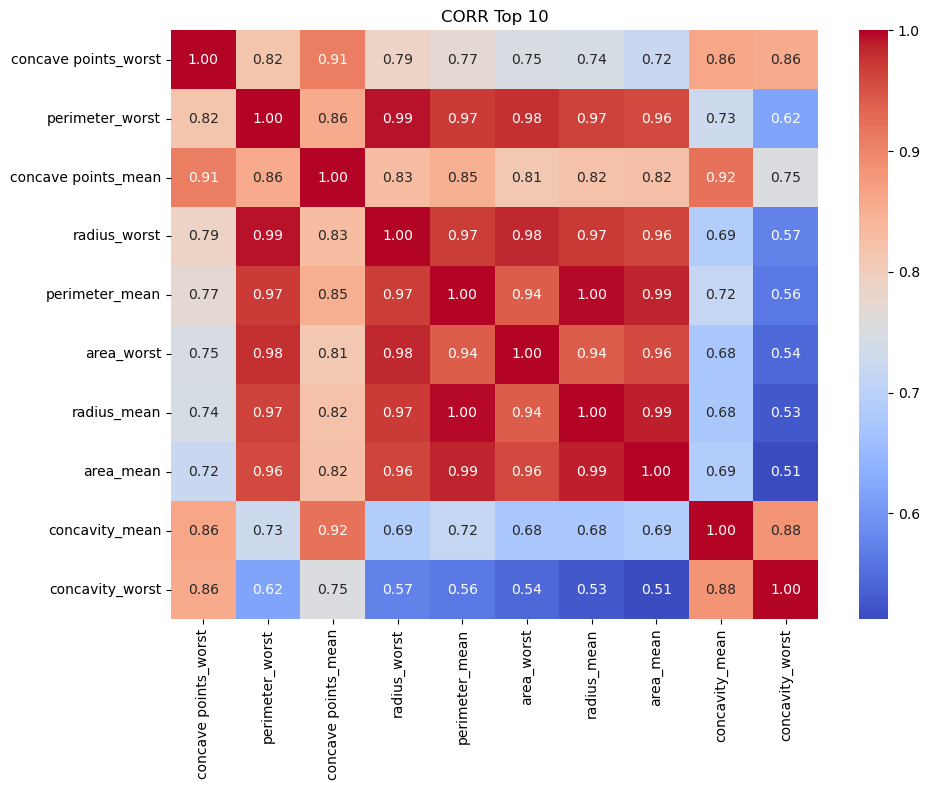

In [16]:
top10 = corr_with_target.abs().sort_values(ascending=False).head(10).index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(df[top10].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("CORR Top 10")
plt.tight_layout()
plt.show()

C:\Users\ACAR\AppData\Local\Temp\ipykernel_12100\2993146789.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="diagnosis", palette="Set2")


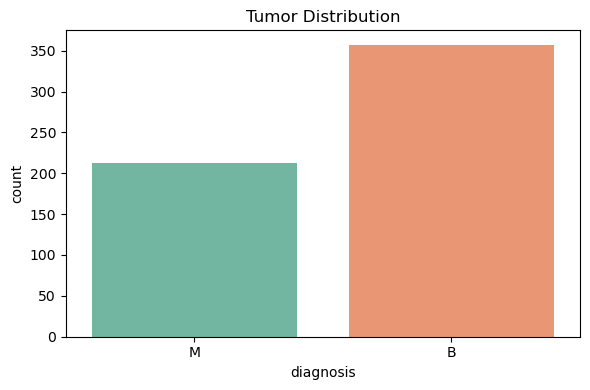

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="diagnosis", palette="Set2")
plt.title("Tumor Distribution")
plt.tight_layout()
plt.show()

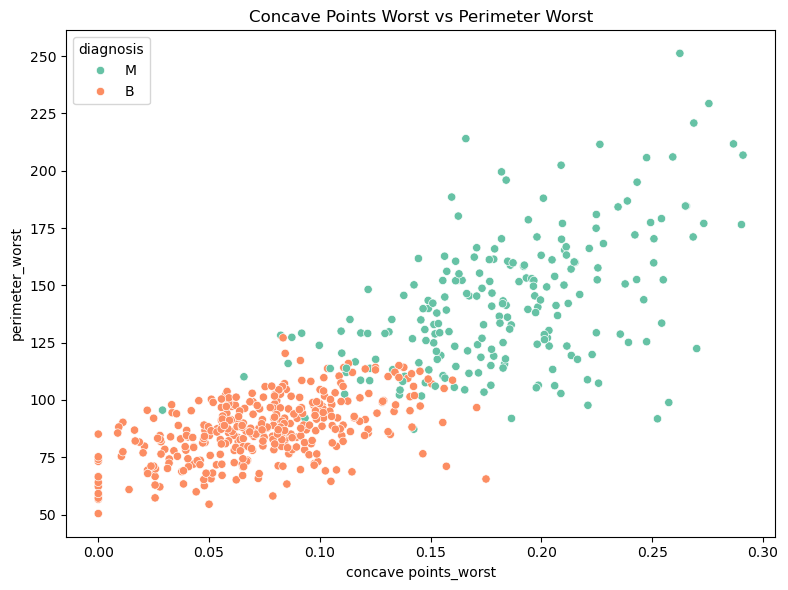

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="concave points_worst",
    y="perimeter_worst",
    hue="diagnosis",
    palette="Set2",
)
plt.title("Concave Points Worst vs Perimeter Worst")
plt.tight_layout()
plt.show()

In [19]:
X = df.drop(["diagnosis", "diagnosis_num"], axis=1)
y = (df["diagnosis"] == "M").astype(int)

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)                                        

In [22]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (455, 30)
Test: (114, 30)


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, StratifiedKFold

models = {
    "Logistic Regression":LogisticRegression(max_iter=1000, random_state=42),
    "SVM":SVC(probability=True, random_state=42),
    "Random Forest":RandomForestClassifier(random_state=42),
    "XGBoost":XGBClassifier(eval_metric="logloss", random_state=42),
    "KNN":KNeighborsClassifier()
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

In [24]:
for name, model in models.items():
    pipeline = Pipeline([("scaler", StandardScaler()),("model", model)])
    
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=["recall", "f1", "roc_auc"], n_jobs=-1)
    
    results[name] = {
        "Recall":scores["test_recall"].mean(),
        "F1":scores["test_f1"].mean(),
        "ROC-AUC":scores["test_roc_auc"].mean()
    }

In [25]:
results_df = pd.DataFrame(results).T.sort_values("Recall", ascending=False)
print(results_df)

                       Recall        F1   ROC-AUC
Logistic Regression  0.952941  0.964048  0.995769
XGBoost              0.952941  0.956001  0.992260
SVM                  0.947059  0.960987  0.994943
Random Forest        0.941176  0.951945  0.988906
KNN                  0.917647  0.951042  0.987100


In [26]:
from sklearn.model_selection import RandomizedSearchCV

In [27]:
param_grid = {
    "model__n_estimators":[100, 200, 300, 500],
    "model__learning_rate":[0.01, 0.05, 0.1, 0.2],
    "model__max_depth":[3, 4, 5, 6, 7],
    "model__subsample":[0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree":[0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight":[1, 3, 5]
}

In [28]:
xgb_pipeline = Pipeline([("scaler", StandardScaler()),("model", XGBClassifier(eval_metric="logloss", random_state=42))])

In [29]:
random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,
    n_iter=50,
    scoring="recall",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [31]:
random_search.fit(X_train, y_train)

print("best params: ",random_search.best_params_)
random_search.best_score_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
best params:  {'model__subsample': 0.7, 'model__n_estimators': 100, 'model__min_child_weight': 1, 'model__max_depth': 3, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.9}


np.float64(0.9588235294117646)

In [32]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n ",cm)

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114

ROC-AUC: 0.9931
Confusion matrix:
  [[72  0]
 [ 4 38]]


In [33]:
from sklearn.metrics import recall_score, precision_score

for t in [0.2, 0.3, 0.4, 0.5, 0.6]:
    pred_t = (y_proba >= t).astype(int)
    cm_t = confusion_matrix(y_test, pred_t)
    print(f"Esik: {t} | Recall: {recall_score(y_test, pred_t):.4f} | "
          f"Precision: {precision_score(y_test, pred_t, zero_division=0):.4f} | "
          f"FN: {cm_t[1,0]} | FP: {cm_t[0,1]}")

Esik: 0.2 | Recall: 0.9762 | Precision: 0.9762 | FN: 1 | FP: 1
Esik: 0.3 | Recall: 0.9524 | Precision: 1.0000 | FN: 2 | FP: 0
Esik: 0.4 | Recall: 0.9286 | Precision: 1.0000 | FN: 3 | FP: 0
Esik: 0.5 | Recall: 0.9048 | Precision: 1.0000 | FN: 4 | FP: 0
Esik: 0.6 | Recall: 0.9048 | Precision: 1.0000 | FN: 4 | FP: 0


In [34]:
import joblib

THRESHOLD = 0.2
joblib.dump(best_model, "cancer_pipeline.pkl")
print("Model kaydedildi: cancer_pipeline.pkl")
print(f"Kullanılan esik: {THRESHOLD}")

Model kaydedildi: cancer_pipeline.pkl
Kullanılan esik: 0.2
